In [1]:
# imports
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

# Loading in the Data

In [2]:
YCRDataPreparedFilepath = '../data/FinalCleanYelpData.csv'

In [3]:
YCRDataPrepared = pd.read_csv(YCRDataPreparedFilepath)
YCRDataPrepared

,Name,Latitude,Longitude,Distance,Price,Rating,Distance_mean,Distance_min,Distance_max,Bike Spots Near,Category,Rounded Latitude,Rounded Longitude,Rounded Distance,Rounded Distance_mean
0,Ravintola Vinkkeli,60.163900,24.946410,993.930059,Most Expensive,5.0,652.820553,104.417207,993.930059,28,Modern European,60.164,24.946,993.930,652.821
1,Baskeri & Basso,60.157873,24.934694,906.269559,Affordable,4.8,673.116165,83.377593,978.824142,16,Bistros,60.158,24.935,906.270,673.116
2,Chef & Sommelier,60.157660,24.942540,489.112498,Most Expensive,4.8,641.800023,134.034975,943.511457,14,Scandinavian,60.158,24.943,489.112,641.800
3,Spis,60.163631,24.947679,910.667273,Most Expensive,4.8,636.883659,122.448928,951.268827,24,Scandinavian,60.164,24.948,910.667,636.884
4,Ani,60.157150,24.933661,941.072231,Affordable,4.5,718.839949,163.361331,995.254401,16,Turkish,60.157,24.934,941.072,718.840
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9730,Karhu Ministeri,60.189571,24.917259,705.595387,Affordable,3.3,511.016285,192.545596,902.743177,11,Pubs,60.190,24.917,705.595,511.016
9731,Ravintola Lehtovaara,60.183600,24.915930,542.047402,Most Expensive,3.3,592.193958,190.699671,961.362096,9,Scandinavian,60.184,24.916,542.047,592.194
9732,Boatip,60.184929,24.941851,891.112679,Most Affordable,4.0,858.743008,826.373336,891.112679,2,Thai,60.185,24.942,891.113,858.743
9733,Diyalo,60.184676,24.923223,125.893234,Affordable,4.0,527.561874,125.893234,909.115155,7,Himalayan/Nepalese,60.185,24.923,125.893,527.562


# Building a regression model

In [4]:
# X are features Y is target.
X_Numeric = YCRDataPrepared[['Rounded Latitude','Rounded Longitude','Rating','Rounded Distance','Rounded Distance_mean']]
y = YCRDataPrepared['Bike Spots Near']

In [5]:
X_Numeric

,Rounded Latitude,Rounded Longitude,Rating,Rounded Distance,Rounded Distance_mean
0,60.164,24.946,5.0,993.930,652.821
1,60.158,24.935,4.8,906.270,673.116
2,60.158,24.943,4.8,489.112,641.800
3,60.164,24.948,4.8,910.667,636.884
4,60.157,24.934,4.5,941.072,718.840
...,...,...,...,...,...
9730,60.190,24.917,3.3,705.595,511.016
9731,60.184,24.916,3.3,542.047,592.194
9732,60.185,24.942,4.0,891.113,858.743
9733,60.185,24.923,4.0,125.893,527.562


In [6]:
y

0       28
1       16
2       14
3       24
4       16
        ..
9730    11
9731     9
9732     2
9733     7
9734     5
Name: Bike Spots Near, Length: 9735, dtype: int64

In [7]:
# checking for correlation. the closwer a value is to 1, the more correlated; no codependency issues here.
CorrelationMatrix = YCRDataPrepared.corr(numeric_only=True)
CorrelationMatrix

,Latitude,Longitude,Distance,Rating,Distance_mean,Distance_min,Distance_max,Bike Spots Near,Rounded Latitude,Rounded Longitude,Rounded Distance,Rounded Distance_mean
Latitude,1.000000,0.332180,-0.072395,-0.291110,-0.225244,-0.141155,-0.127531,-0.136595,0.999970,0.332266,-0.072395,-0.225244
Longitude,0.332180,1.000000,0.010182,0.060689,0.031680,0.058445,-0.086827,0.015129,0.331948,0.999994,0.010182,0.031680
Distance,-0.072395,0.010182,1.000000,0.045317,0.321408,0.216417,0.147196,-0.024512,-0.072384,0.010194,1.000000,0.321408
Rating,-0.291110,0.060689,0.045317,1.000000,0.140995,0.000661,0.173716,0.416197,-0.291520,0.060767,0.045317,0.140995
Distance_mean,-0.225244,0.031680,0.321408,0.140995,1.000000,0.673341,0.457971,-0.076264,-0.225208,0.031717,0.321408,1.000000
Distance_min,-0.141155,0.058445,0.216417,0.000661,0.673341,1.000000,-0.090176,-0.394952,-0.141270,0.058352,0.216417,0.673340
Distance_max,-0.127531,-0.086827,0.147196,0.173716,0.457971,-0.090176,1.000000,0.380365,-0.127487,-0.086773,0.147196,0.457971
Bike Spots Near,-0.136595,0.015129,-0.024512,0.416197,-0.076264,-0.394952,0.380365,1.000000,-0.136525,0.015216,-0.024512,-0.076264
Rounded Latitude,0.999970,0.331948,-0.072384,-0.291520,-0.225208,-0.141270,-0.127487,-0.136525,1.000000,0.332035,-0.072384,-0.225208
Rounded Longitude,0.332266,0.999994,0.010194,0.060767,0.031717,0.058352,-0.086773,0.015216,0.332035,1.000000,0.010194,0.031717


In [8]:
# splitting the data
X_train, X_test, y_train, y_test = train_test_split(X_Numeric,y, test_size=0.2, random_state=42)

In [9]:
# adding a constant
X_train = sm.add_constant(X_train)
X_test = sm.add_constant(X_test)


In [10]:
# setting up the model
LinReg = sm.OLS(y_train, X_train)

In [11]:
# fitting the model
Model = LinReg.fit()

## Model Output and Interpretation

In [12]:
ModelOutput = Model.summary()
print(ModelOutput)

                            OLS Regression Results                            
Dep. Variable:        Bike Spots Near   R-squared:                       0.191
Model:                            OLS   Adj. R-squared:                  0.190
Method:                 Least Squares   F-statistic:                     367.3
Date:                Tue, 25 Mar 2025   Prob (F-statistic):               0.00
Time:                        16:58:22   Log-Likelihood:                -26254.
No. Observations:                7788   AIC:                         5.252e+04
Df Residuals:                    7782   BIC:                         5.256e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                   495.23

# old model

In [21]:
ModelOutput = Model.summary()
print(ModelOutput)

                            OLS Regression Results                            
Dep. Variable:        Bike Spots Near   R-squared:                       0.194
Model:                            OLS   Adj. R-squared:                  0.193
Method:                 Least Squares   F-statistic:                     467.7
Date:                Mon, 03 Mar 2025   Prob (F-statistic):               0.00
Time:                        10:46:35   Log-Likelihood:                -32868.
No. Observations:                9735   AIC:                         6.575e+04
Df Residuals:                    9729   BIC:                         6.579e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                   610.61

The adjusted R-squared indicates to us that the model explains 19.3% of the data. The R-squared and adjusted R-squared being close to each other suggests that all of the features in the model are relevant to the prediction made.
___

The F-statistic for this model has a null hypothesis that a model made with only the constant coefficient value of 610.6147 is equal to this model made with the features Rounded Latitude, Rounded Longitude, Rating, Rounded Distance, and Rounded Distance_mean. The Prob (F-statistic) value being less than 0.05 is strong evidence against the null hypothesis. We can accept the alternate hypothesis that the model only using the constant coefficient is worse than this model made with the features Rounded Latitude, Rounded Longitude, Rating, Rounded Distance, and Rounded Distance_mean.
___

Our confidence interval for the t-test is 95%. The p values of Rounded Longitude and Rounded Distance are above the 0.05 threshold that we want. This means that the relationship between those two features and the number of bike spots in an area is most likely from natural variation as opposed to the number of bike spots being related to the feature.
___
For the other features (Rounded Latitude, Rating, and Rounded Distance_mean), the p values are below the 0.05 threshold. This means that those three features and the number of bike spots in an area are most likely related to each other.

___
As explained by the R-squared and p-values, the features likely don't actually have any effect on the target. Therefore the below interpretations of coefficients aren't indicative of an actual change as calculated by the model.

The model's coefficient values show that as one of Rounded Longitude and Rating go up, the number of bike spots near goes up; when one of those values goes down, the number of bike spots goes down. The other features (Rounded Latitude, Rounded Distance, and Rounded Distance_mean) have a negative impact on the number of bike spots (when one goes up the other goes down, and vice versa). 

    The coefficient indicates that:
- as the Rounded Latitude increases by 1, the amount of bike spots is expected to decrease by 10.4190. 
- as the Rounded Longitude increases by 1, the amount of bike spots is expected to increase by 1.0170 on average. 
- as the Rating increases by 1, the amount of bike spots is expected to increase by 3.583 on average.
- as the Rounded Distance increases by 1, the amount of bike spots is expected to decrease by 7.007e-10 on average, which is an extremely small number. 
- as the Rounded Distance_mean increases by 1, the amount of bike spots is expected to decrease by 0.0141 on average.

In [ ]:
# adjusting the model by removing the feature with the highest p-value
xAdjusted = X_Numeric.drop(columns=['Rounded Distance'])
xAdjusted = sm.add_constant(xAdjusted) # adding a constant
LinRegAdj = sm.OLS(y,xAdjusted)
ModelAdjusted = LinRegAdj.fit()
ModelAdjustedOutput = ModelAdjusted.summary()
print(ModelAdjustedOutput)

                            OLS Regression Results                            
Dep. Variable:        Bike Spots Near   R-squared:                       0.194
Model:                            OLS   Adj. R-squared:                  0.193
Method:                 Least Squares   F-statistic:                     584.6
Date:                Wed, 05 Mar 2025   Prob (F-statistic):               0.00
Time:                        16:40:57   Log-Likelihood:                -32868.
No. Observations:                9735   AIC:                         6.575e+04
Df Residuals:                    9730   BIC:                         6.578e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                   610.61

Adjusting the model doesn't have the model explain any more of the data and it doesn't move the p values closer to the desired value of 0.05 or lower. We will remove the remaining feature that doesn't meet the desired value.

In [11]:
# adjusting the model by removing the feature with the highest p-value
xAdjusted2 = xAdjusted.drop(columns=['Rounded Longitude'])
xAdjusted2 = sm.add_constant(xAdjusted2) # adding a constant
LinRegAdj2 = sm.OLS(y,xAdjusted2)
ModelAdjusted2 = LinRegAdj2.fit()
ModelAdjustedOutput2 = ModelAdjusted2.summary()
print(ModelAdjustedOutput2)

                            OLS Regression Results                            
Dep. Variable:        Bike Spots Near   R-squared:                       0.194
Model:                            OLS   Adj. R-squared:                  0.193
Method:                 Least Squares   F-statistic:                     779.1
Date:                Wed, 12 Mar 2025   Prob (F-statistic):               0.00
Time:                        19:57:41   Log-Likelihood:                -32869.
No. Observations:                9735   AIC:                         6.575e+04
Df Residuals:                    9731   BIC:                         6.577e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                   580.70

Now all of the model's features are able to reject the null hypothesis and accept the alternate hypothesis stating that the weight values of these particular features are non-zero. So Rounded Latitude, Rating, and Rounded Distance_mean all have an impact on predicting the amount of Bke Spots Near.

---

# Building a model using categorical features

In [4]:
# using label encoder
LabelEncoders = {}
for column in ['Price','Category']:
    LabelEncoders[column] = LabelEncoder()
    YCRDataPrepared[column] = LabelEncoders[column].fit_transform(YCRDataPrepared[column])


In [5]:
X_Categoric = YCRDataPrepared[['Price','Category']]
y = YCRDataPrepared['Bike Spots Near']

In [8]:
# splitting data into training and testing
X_train, X_test, y_train, y_test = train_test_split(X_Categoric, y, test_size=0.2, random_state=42)

In [9]:
# training the model
# taking into account that the y value here is a continuous value
xgbModel = xgb.XGBRegressor(objective='reg:squarederror')
xgbModel.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

## Model Output and Interpretation

In [17]:
# predicting Bike Spots Near using the model
y_pred = xgbModel.predict(X_test)
y_pred

array([13.117591 ,  7.6184077,  8.365369 , ..., 11.029809 , 15.153408 ,
       13.117591 ], dtype=float32)

In [ ]:
# calculating R^2 (Coefficient of Determination)
xgbModelR2 = r2_score(y_test,y_pred)
print(f'R^2: {xgbModelR2}')

# adjusted R^2
xgbModelAdjR2 = 1-(((1-xgbModelR2)*(len(X_test)-1))/(len(X_test)-len(X_test.columns)-1))
print(f'Adjusted R^2: {xgbModelAdjR2}')

R^2: 0.47913068532943726
Adjusted R^2: 0.521405188451088


The adjusted R-squared shows us that the model explains 52.1% of the data. The R-squared being 0.47913068532943726 while the Adjusted R-squared is 0.521405188451088 suggests that not all features used in the model are relevant to the prediction made.

In [ ]:
# evaluating the model
xgbModelMSE = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {xgbModelMSE}')
# getting RMSE to have more interpretability 
xgbModelRMSE = np.sqrt(xgbModelMSE)
print(f'Root Mean Squared Error: {xgbModelRMSE}')

Mean Squared Error: 34.14254379272461
Root Mean Squared Error: 5.84316213986268


The MSE is strongly affected by outliers, so this relatively large number of 34.14254379272461, especially in comparison to the RMSE of 5.84316213986268 indicates outliers.

The Root Mean Squared Error being 5.84316213986268 means that the model's predictions are off by 5.84316213986268 Bike Spots Near on average. This is rather large, especially if it's one person looking for Bike Spots for themself.

In [28]:
# calculating Mean Absolute Error
xgbModelMAE = mean_absolute_error(y_test,y_pred)
print(f'Mean Absolute Error: {xgbModelMAE}')

Mean Absolute Error: 4.414535045623779


The Mean Absolute Error doesn't take outliers into consideration. According to this metric, a value of 4.414535045623779 means that the model's predictions are off by 4.414535045623779 Bike Spots Near on average. This is rather large, especially if it's one person looking for Bike Spots for themself.

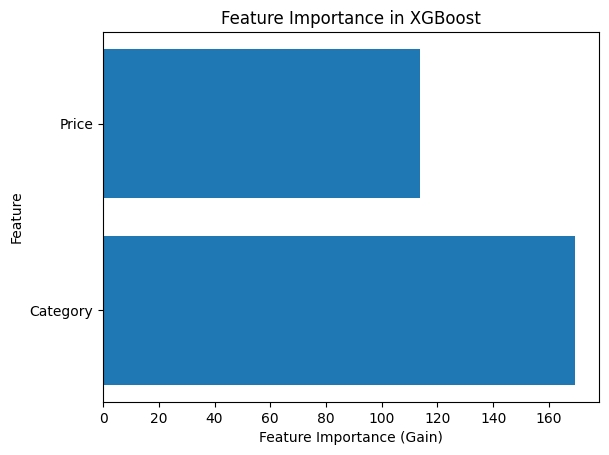

    Feature  Importance
1  Category  169.505844
0     Price  113.732826


In [ ]:
# evaluating the relevance of each feature to the model

# getting feature importance
FeatureImportance = xgbModel.get_booster().get_score(importance_type='gain')

# converting the results into a dataframe
FeatureImportanceDF = pd.DataFrame(FeatureImportance.items(), columns=['Feature', 'Importance']).sort_values(by='Importance', ascending=False)

# Plot feature importance
plt.barh(FeatureImportanceDF['Feature'], FeatureImportanceDF['Importance'])
plt.xlabel('Feature Importance (Gain)')
plt.ylabel('Feature')
plt.title('Feature Importance in XGBoost')
plt.show()

print(FeatureImportanceDF)


The gain is measuring the average improvement of the model's ability to predict the target when a feature is used. Using this metric, the Category column is more relevant to the model than the Price column.

# Combining Features

I want to see if combining all the features that were found to have an impact on the prediction into one model will improve the predictive power.

- create a dataframe with only the features being tested


In [6]:
# dropping the numeric features that were determined not to be relevant to predicting Bike Spots Near
X_Numeric_Values = YCRDataPrepared[['Rounded Latitude','Rating','Rounded Distance_mean']]
X_Numeric_Values

,Rounded Latitude,Rating,Rounded Distance_mean
0,60.164,5.0,652.821
1,60.158,4.8,673.116
2,60.158,4.8,641.800
3,60.164,4.8,636.884
4,60.157,4.5,718.840
...,...,...,...
9730,60.190,3.3,511.016
9731,60.184,3.3,592.194
9732,60.185,4.0,858.743
9733,60.185,4.0,527.562


In [7]:
# combining all relevant features into one dataframe
X_Combined = pd.concat([X_Numeric_Values, X_Categoric], axis=1)
X_Combined

,Rounded Latitude,Rating,Rounded Distance_mean,Price,Category
0,60.164,5.0,652.821,3,79
1,60.158,4.8,673.116,0,12
2,60.158,4.8,641.800,3,100
3,60.164,4.8,636.884,3,100
4,60.157,4.5,718.840,0,117
...,...,...,...,...,...
9730,60.190,3.3,511.016,0,92
9731,60.184,3.3,592.194,3,100
9732,60.185,4.0,858.743,2,115
9733,60.185,4.0,527.562,0,57


In [8]:
# splitting the combined data into training and testing
Combined_X_train, Combined_X_test, Combined_y_train, Combined_y_test = train_test_split(X_Combined, y, test_size=0.2, random_state=42)

In [9]:
# training the model
# taking into account that the y value here is a continuous value
Combined_xgbModel = xgb.XGBRegressor(objective='reg:squarederror')
Combined_xgbModel.fit(Combined_X_train, Combined_y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

## Model Output and Interpretation

In [10]:
# predicting Bike Spots Near using the model
Combined_y_pred = Combined_xgbModel.predict(Combined_X_test)
Combined_y_pred

array([ 7.1252985,  9.085804 ,  7.346952 , ...,  9.167214 , 30.893787 ,
       14.896217 ], dtype=float32)

In [11]:
# calculating R^2 (Coefficient of Determination)
Combined_xgbModelR2 = r2_score(Combined_y_test,Combined_y_pred)
print(f'R^2: {Combined_xgbModelR2}')

# adjusted R^2
Combined_xgbModelAdjR2 = 1-(((1-Combined_xgbModelR2)*(len(Combined_X_test)-1))/(len(Combined_X_test)-len(Combined_X_test.columns)-1))
print(f'Adjusted R^2: {Combined_xgbModelAdjR2}')

R^2: 0.9962732791900635
Adjusted R^2: 0.9962636791879771


The adjusted R-squared shows us that the model explains 99.6% of the data. The R-squared being 0.9962732791900635 while the Adjusted R-squared is 0.9962636791879771 suggests that not all features used in the model are relevant to the prediction made, and that features can be dropped for a more accurate model.

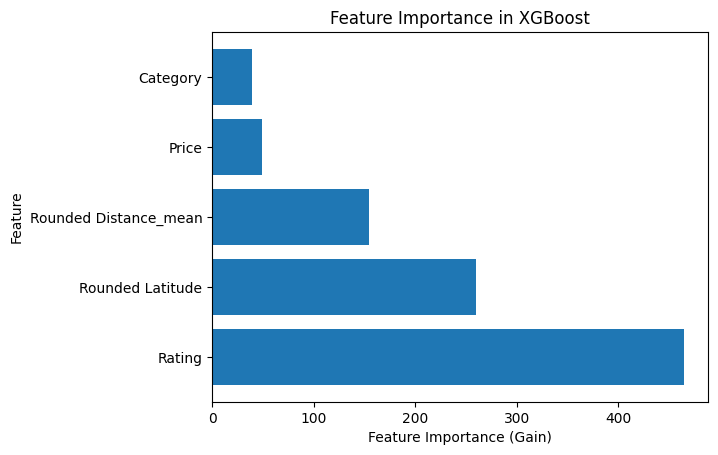

                 Feature  Importance
1                 Rating  464.914032
0       Rounded Latitude  259.960236
2  Rounded Distance_mean  154.629227
3                  Price   49.219872
4               Category   39.055988


In [12]:
# evaluating the relevance of each feature to the model

# getting feature importance
Combined_FeatureImportance = Combined_xgbModel.get_booster().get_score(importance_type='gain')

# converting the results into a dataframe
Combined_FeatureImportanceDF = pd.DataFrame(Combined_FeatureImportance.items(), columns=['Feature', 'Importance']).sort_values(by='Importance', ascending=False)

# Plot feature importance
plt.barh(Combined_FeatureImportanceDF['Feature'], Combined_FeatureImportanceDF['Importance'])
plt.xlabel('Feature Importance (Gain)')
plt.ylabel('Feature')
plt.title('Feature Importance in XGBoost')
plt.show()

print(Combined_FeatureImportanceDF)

The gain is measuring the average improvement of the model's ability to predict the target when a feature is used. Using this metric, the Category and Price columns are far less relevant to the model than Rating, Rounded Latitude, and Rounded Distance_mean. This is able to happen because the models have different areas that they perform best in. 

Ordinary Least Squares regression model assumes that changes in the feature(s) always result in a proportional change in the target, whereas the XGBoost Regressor model is able to account for complex relationships between feature(s) and the target.

In [12]:
# dropping Category to see how much better the model performs
X_Combined_2 = X_Combined.drop(columns=['Category'])
X_Combined_2

,Rounded Latitude,Rating,Rounded Distance_mean,Price
0,60.164,5.0,652.821,3
1,60.158,4.8,673.116,0
2,60.158,4.8,641.800,3
3,60.164,4.8,636.884,3
4,60.157,4.5,718.840,0
...,...,...,...,...
9730,60.190,3.3,511.016,0
9731,60.184,3.3,592.194,3
9732,60.185,4.0,858.743,2
9733,60.185,4.0,527.562,0


In [13]:
# splitting the combined data into training and testing
Combined_X_2_train, Combined_X_2_test, Combined_y_2_train, Combined_y_2_test = train_test_split(X_Combined_2, y, test_size=0.2, random_state=42)

In [14]:
# training the model
# taking into account that the y value here is a continuous value
Combined_xgbModel_2 = xgb.XGBRegressor(objective='reg:squarederror')
Combined_xgbModel_2.fit(Combined_X_2_train, Combined_y_2_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [15]:
# predicting Bike Spots Near using the model
Combined_y_2_pred = Combined_xgbModel_2.predict(Combined_X_2_test)
Combined_y_2_pred

array([ 7.020946,  9.47182 ,  7.675827, ...,  8.764751, 30.864584,
       15.213117], dtype=float32)

In [17]:
# calculating R^2 (Coefficient of Determination)
Combined_xgbModel_2_R2 = r2_score(Combined_y_2_test,Combined_y_2_pred)
print(f'R^2: {Combined_xgbModel_2_R2}')

# adjusted R^2
Combined_xgbModel_2_AdjR2 = 1-(((1-Combined_xgbModel_2_R2)*(len(Combined_X_2_test)-1))/(len(Combined_X_2_test)-len(Combined_X_2_test.columns)-1))
print(f'Adjusted R^2: {Combined_xgbModel_2_AdjR2}')

R^2: 0.99558025598526
Adjusted R^2: 0.9955711524960432


The adjusted R-squared shows us that the model explains 99.5% of the data. This is less than the previous model.

The R-squared being 0.99558025598526 while the Adjusted R-squared is 0.9955711524960432 suggests that not all features used in the model are relevant to the prediction made, and that features can be dropped for a more accurate model.

In [17]:
# evaluating the first combined model
Combined_xgbModelMSE = mean_squared_error(Combined_y_test,Combined_y_pred)
print(f'Mean Squared Error: {Combined_xgbModelMSE}')
# getting RMSE to have more interpretability 
Combined_xgbModelRMSE = np.sqrt(Combined_xgbModelMSE)
print(f'Root Mean Squared Error: {Combined_xgbModelRMSE}')

Mean Squared Error: 0.24428324401378632
Root Mean Squared Error: 0.4942501836254452


In [18]:
# evaluating the second combined model
Combined_xgbModel_2MSE = mean_squared_error(Combined_y_2_test,Combined_y_2_pred)
print(f'Mean Squared Error: {Combined_xgbModel_2MSE}')
# getting RMSE to have more interpretability 
Combined_xgbModel_2RMSE = np.sqrt(Combined_xgbModel_2MSE)
print(f'Root Mean Squared Error: {Combined_xgbModel_2RMSE}')

Mean Squared Error: 0.28971222043037415
Root Mean Squared Error: 0.5382492177703319


### Mean Squared Error
For the first combined model, the model's predictions are off by 0.24428324401378632 Bike Spots Near on average.
For the second combined model, the model's predictions are off by 0.28971222043037415 Bike Spots Near on average.



Using the MSE metric, the first combined model performs better than both the second combined model and the previous best model where the predictions are off by 34.14254379272461 Bike Spots Near on average. 

The MSE metric is more affected by outliers than the RMSE metric. Using the MSE metric, the first combined model performs better than both the second combined model and the previous best model where the predictions are off by 34.1425437927246 Bike Spots Near on average.

### Root Mean Squared Error
For the first combined model, the model's predictions are off by 0.4942501836254452 Bike Spots Near on average.
For the second combined model, the model's predictions are off by 0.5382492177703319 Bike Spots Near on average.

This isn't that large considering it's less than a whole Bike Spot, which is how they are measured, but the average isn't indicative of the difference of any given result.

Using the RMSE metric, the first combined model performs better than both the second combined model and the previous best model where the predictions are off by 5.84316213986268 Bike Spots Near on average.

In [21]:
# calculating Mean Absolute Error for the first combined model
Combined_xgbModelMAE = mean_absolute_error(Combined_y_test,Combined_y_pred)
print(f'Mean Absolute Error: {Combined_xgbModelMAE}')

Mean Absolute Error: 0.24501222372055054


In [22]:
# calculating Mean Absolute Error for the second combined model
Combined_xgbModelMAE = mean_absolute_error(Combined_y_2_test,Combined_y_2_pred)
print(f'Mean Absolute Error: {Combined_xgbModelMAE}')

Mean Absolute Error: 0.3033435344696045


### Mean Absolute Error
For the first combined model, the model's predictions are off by 0.24501222372055054 Bike Spots Near on average.
For the second combined model, the model's predictions are off by 0.3033435344696045 Bike Spots Near on average.

The models' predictions are interpreted as better here because the Mean Absolute Error doesn't take outliers into consideration. 

Using the MAE metric, the first combined model performs better than both the second combined model and the previous best model where the predictions are off by 4.414535045623779 Bike Spots Near on average.
